# Car Dimensions: A Look Through Time

Have cars of the same model grown larger over the years, or does the change in size depend on the specific model?

To explore this question, we have a dataset in the file `car-dimensions.csv`, which presents the `length`, `width`, and `height` (all in millimeters) for 53 car models. This dataset includes measurements from the earliest generation of each model that we could find, as well as data from the latest model. 

By analyzing this information, we can uncover trends and patterns in the evolution of car dimensions over time.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'car-dimensions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('car-dimensions.csv')
df.head(4)

,brand_model,length,width,height,year,generation
0,Audi A4,4520,1733,1415,1994,first
1,Audi A4,4762,1847,1427,2015,latest
2,BMW 3 Series,4355,1610,1380,1975,first
3,BMW 3 Series,4829,1827,1442,2018,latest


In [3]:
first_generation = df.query('generation == "first"')
first_generation.head(2)

,brand_model,length,width,height,year,generation
0,Audi A4,4520,1733,1415,1994,first
2,BMW 3 Series,4355,1610,1380,1975,first


In [4]:
latest_generation = df.query('generation == "latest"')
latest_generation.head(2)

,brand_model,length,width,height,year,generation
1,Audi A4,4762,1847,1427,2015,latest
3,BMW 3 Series,4829,1827,1442,2018,latest


In [5]:
# helper function, change gap, vertical alignment, horizontal alignment, placement of gap...
def add_labels(df, x_col, y_col, label_col):
	for i, row in df.iterrows():
		x = row[x_col]
		y = row[y_col]
		gap = "  "
		label = gap + row[label_col]
		plt.text(x, y, label, va='center', ha='left')

### Project Ideas
- Create paired scatter plots of car `width`, `length`, or `height`.

- Follow the Pro Tips.

- Add labels to datapoints to tell a story.

- Create new variables such as:
	- `car footprint = (length * width)`
	- `percent change = (latest - first) / first`
	
- Create horizontal bar plots showing which car models have changed the least or most for a variable of your choice.

Below is a preliminary paired scatter plot of car `length` to get you started. 

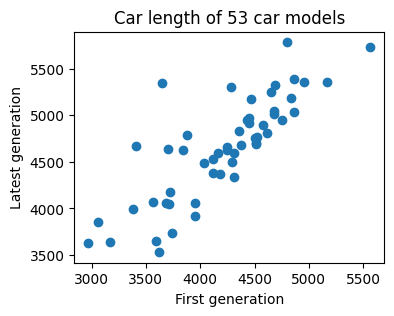

In [6]:
plt.figure(figsize=(4, 3))  
plt.scatter(first_generation['length'], latest_generation['length'])
plt.xlabel('First generation')
plt.ylabel('Latest generation')
plt.title('Car length of 53 car models')
plt.show()

In [7]:
# YOUR CODE HERE (add additional cells as needed)

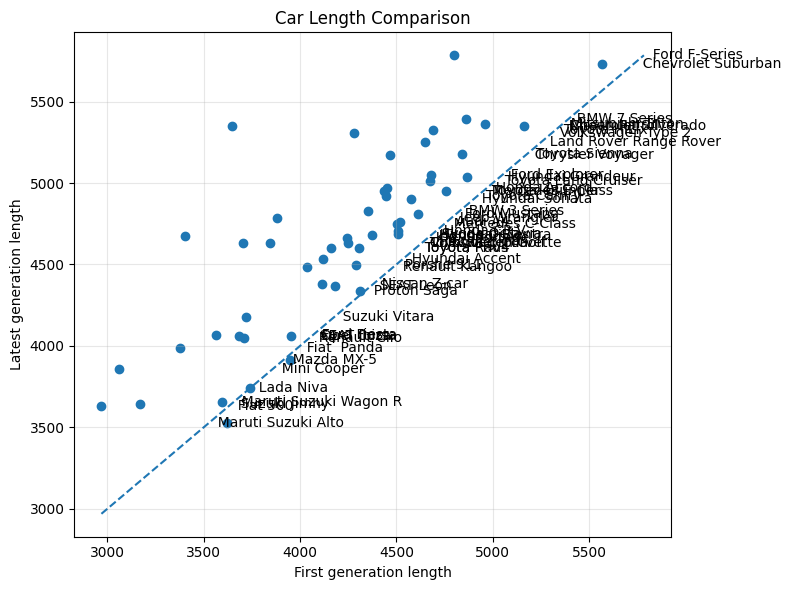

In [9]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    first_generation['length'],
    latest_generation['length']
)

# Add labels
add_labels(
    latest_generation,
    'length',
    'length',
    'brand_model'
)

# 1:1 line
min_val = min(
    first_generation['length'].min(),
    latest_generation['length'].min()
)

max_val = max(
    first_generation['length'].max(),
    latest_generation['length'].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

# Labels
plt.xlabel('First generation length')
plt.ylabel('Latest generation length')

# Title
plt.title('Car Length Comparison')

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

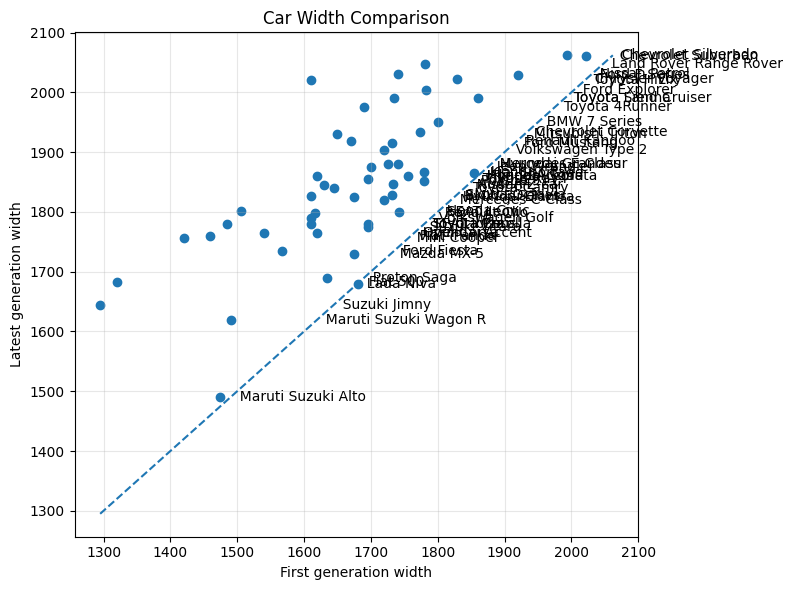

In [11]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    first_generation['width'],
    latest_generation['width']
)

# Add labels
add_labels(
    latest_generation,
    'width',
    'width',
    'brand_model'
)

# 1:1 line
min_val = min(
    first_generation['width'].min(),
    latest_generation['width'].min()
)

max_val = max(
    first_generation['width'].max(),
    latest_generation['width'].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

# Labels
plt.xlabel('First generation width')
plt.ylabel('Latest generation width')

# Title
plt.title('Car Width Comparison')

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

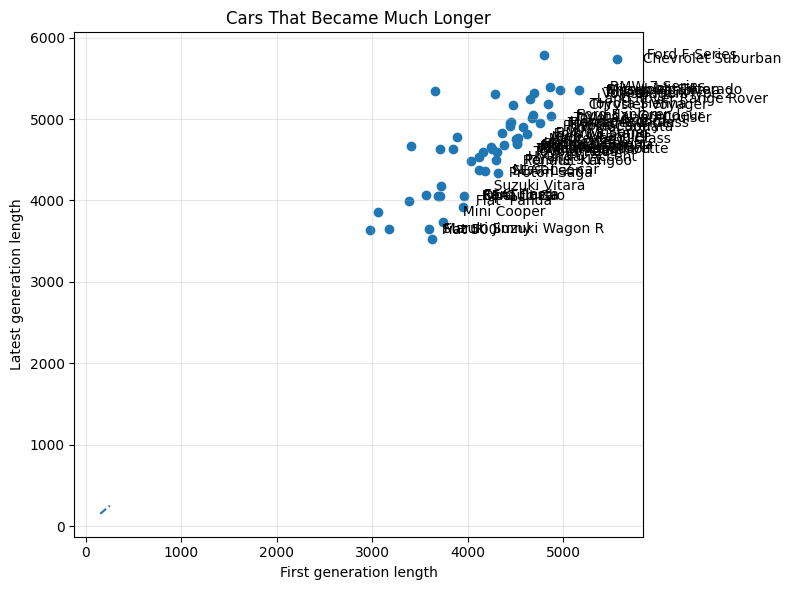

In [12]:
# Calculate difference
latest_generation['length_change'] = (
    latest_generation['length'].values -
    first_generation['length'].values
)

# Filter big increases
bigger_cars = latest_generation[
    latest_generation['length_change'] > 20
]

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    first_generation['length'],
    latest_generation['length']
)

# Labels
add_labels(
    bigger_cars,
    'length',
    'length',
    'brand_model'
)

# 1:1 line
plt.plot(
    [150, 250],
    [150, 250],
    linestyle='--'
)

plt.xlabel('First generation length')
plt.ylabel('Latest generation length')

plt.title('Cars That Became Much Longer')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

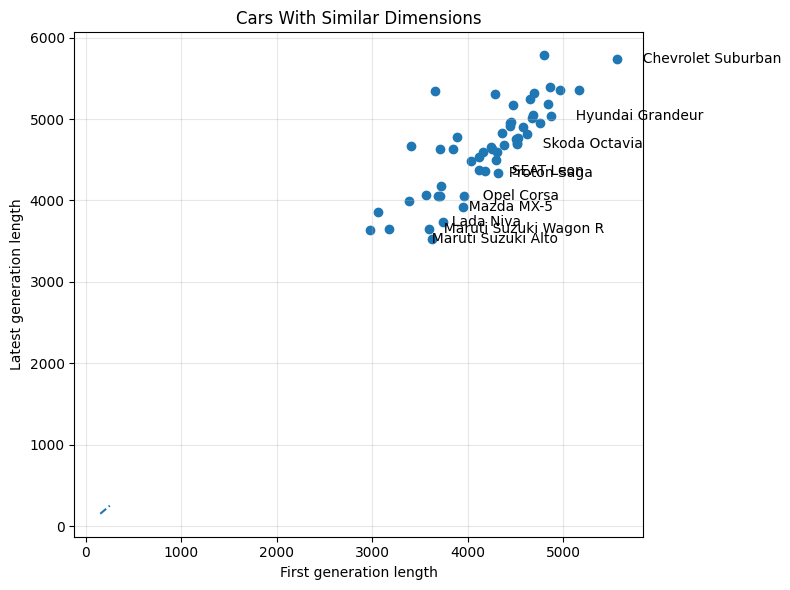

In [14]:
# Distance from equality line
latest_generation['distance'] = abs(
    latest_generation['length'].values -
    first_generation['length'].values
)

# Closest cars
closest = latest_generation.nsmallest(
    10,
    'distance'
)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    first_generation['length'],
    latest_generation['length']
)

# Add labels
add_labels(
    closest,
    'length',
    'length',
    'brand_model'
)

# 1:1 line
plt.plot(
    [150, 250],
    [150, 250],
    linestyle='--'
)

plt.xlabel('First generation length')
plt.ylabel('Latest generation length')

plt.title('Cars With Similar Dimensions')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

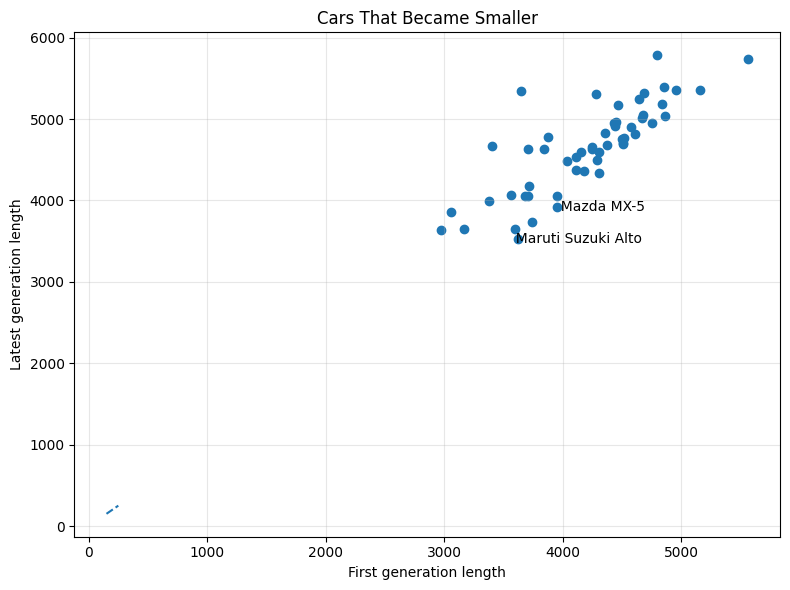

In [15]:
# Smaller cars
smaller = latest_generation[
    latest_generation['length_change'] < -5
]

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    first_generation['length'],
    latest_generation['length']
)

# Labels
add_labels(
    smaller,
    'length',
    'length',
    'brand_model'
)

# 1:1 line
plt.plot(
    [150, 250],
    [150, 250],
    linestyle='--'
)

plt.xlabel('First generation length')
plt.ylabel('Latest generation length')

plt.title('Cars That Became Smaller')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

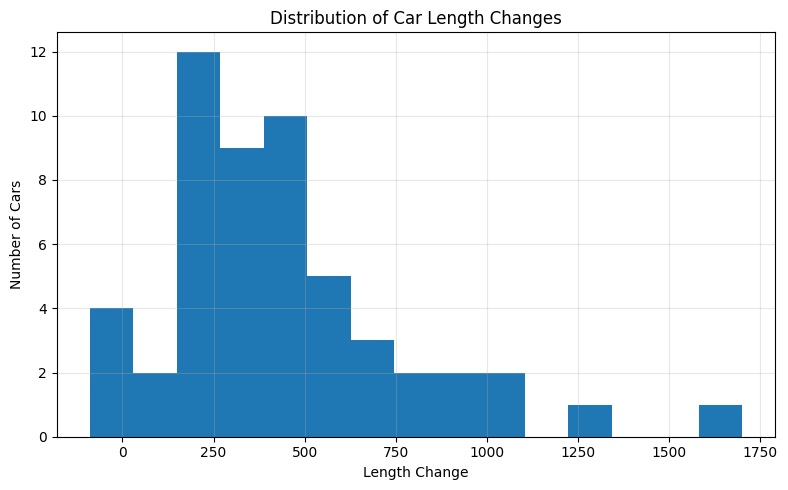

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    latest_generation['length_change'],
    bins=15
)

plt.xlabel('Length Change')

plt.ylabel('Number of Cars')

plt.title('Distribution of Car Length Changes')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [17]:
average_change = latest_generation[
    'length_change'
].mean()

print(
    'Average length increase:',
    round(average_change, 2)
)

Average length increase: 438.58


In [18]:
largest_growth = latest_generation.sort_values(
    'length_change',
    ascending=False
).head(1)

print(largest_growth)

      brand_model  length  width  height  year generation  length_change  \
63  Nissan Patrol    5350   2030    1955  2024     latest           1700   

    distance  
63      1700  
